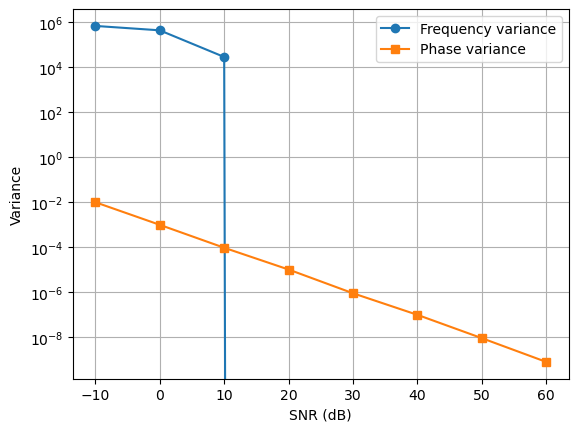

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parametere ---
N = 513
n = np.arange(-256, 257)
T = 1e-6
f0 = 1e5
omega0 = 2 * np.pi * f0
phi = np.pi / 8

# --- Signal ---
def generate_signal(SNR_dB):
    SNR = 10**(SNR_dB / 10)
    sigma2 = 1 / (2 * SNR)

    noise = (np.random.normal(0, np.sqrt(sigma2), N) +
             1j * np.random.normal(0, np.sqrt(sigma2), N))

    x = np.exp(1j * (omega0 * n * T + phi)) + noise
    return x

# --- Frekvens (FFT) ---
def estimate_frequency(x, M):
    X = np.fft.fft(x, n=M)
    m = np.argmax(np.abs(X))
    omega_hat = 2 * np.pi * m / (M * T)
    return omega_hat

# --- Fase ---
def estimate_phase(x, omega_hat):
    F = np.mean(x * np.exp(-1j * omega_hat * n * T))
    return np.angle(F)

# --- Monte Carlo ---
def run_simulation(SNR_dB, M, runs=500):
    omega_err = []
    phi_err = []

    for _ in range(runs):
        x = generate_signal(SNR_dB)

        omega_hat = estimate_frequency(x, M)
        phi_hat = estimate_phase(x, omega_hat)

        omega_err.append(omega0 - omega_hat)
        phi_err.append(phi - phi_hat)

    return np.var(omega_err), np.var(phi_err)

# --- Kjør ---
SNRs = np.arange(-10, 61, 10)
M = 2**12   # velg én først

var_w = []
var_phi = []

for snr in SNRs:
    vw, vp = run_simulation(snr, M)
    var_w.append(vw)
    var_phi.append(vp)

# --- Plot ---
plt.figure()
plt.semilogy(SNRs, var_w, 'o-', label='Frequency variance')
plt.semilogy(SNRs, var_phi, 's-', label='Phase variance')
plt.xlabel('SNR (dB)')
plt.ylabel('Variance')
plt.legend()
plt.grid()
plt.show()